### Four different input settings:
1. Basic: $$F^\mathrm{ST}((\hat{v}, h(\hat{v})) = f_v,$$ $$F^\mathrm{MLP}(\hat{v}, h(\hat{v}), f_v, y^\dag) = \mathrm{Corr Terms}.$$
2. Noise in ST (NST): $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, \hat{y}) = f_v,$$ $$F^\mathrm{MLP}(\hat{v}, h(\hat{v}), f_v, y^\dag) = \mathrm{Corr Terms}.$$
3. Noise in MLP (NMLP): $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, h(\hat{v}) = f_v, $$ $$F^\mathrm{MLP}(\hat{v}, h(\hat{v}), f_v, y^\dag - \hat{y}) = \mathrm{Corr Terms}.$$
4. NST \& NMLP: $$\hat{y} = h(\hat{v}) + \eta,$$ $$F^\mathrm{ST}((\hat{v}, \hat{y}) = f_v, $$ $$F^\mathrm{MLP}(\hat{v}, h(\hat{v}), f_v, y^\dag - \hat{y}) = \mathrm{Corr Terms}.$$

In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

Dynamic: $v_{j+1} = Av_j$, where $A\in \mathbb{R}^{10\times 10}$ is a orthogonal matrix.

In this case, $A$ is randomly chosen:
| | | | | | | | | | |
|---|---|---|---|---|---|---|---|---|---|
| -0.6773| 0.4683| -0.0754| -0.3976| -0.0405| -0.0928| -0.1359| -0.2615| -0.1989| 0.1466|
| 0.1380| -0.4059| 0.2539| -0.1175| 0.0156| -0.2418| -0.7307| -0.2500| -0.2627| 0.1172|
| 0.2665| 0.2850| -0.4592| 0.2285| 0.3907| -0.4428| 0.0035| 0.0075| -0.4759| -0.0972|
| 0.0884| 0.2362| 0.4721| -0.2020| -0.0494| -0.4574| 0.0659| 0.0123| 0.1583| -0.6569|
| 0.5475| 0.2415| 0.0630| -0.4416| -0.3094| -0.1871| 0.2146| -0.0366| -0.0058| 0.5146|
| -0.0274| 0.1503| 0.1875| 0.4052| -0.6749| 0.1035| 0.0110| 0.0950| -0.5424| -0.0887|
| 0.0344| 0.5179| 0.3942| 0.4493| 0.2400| 0.0121| -0.3090| 0.1434| 0.2794| 0.3485|
| 0.3707| 0.3339| -0.1364| -0.0860| 0.0080| 0.5749| -0.2379| -0.4786| 0.0272| -0.3288|
| -0.0038| -0.0953| 0.5282| -0.0213| 0.4483| 0.2132| 0.4421| -0.2687| -0.4318| 0.1045|
| -0.0660| -0.0961| -0.0628| 0.4076| -0.1823| -0.3252| 0.2225| -0.7326| 0.2836| 0.1032|

with eigenvalues: 1.00+0.00i, 0.28+0.96i, 0.28-0.96i, -0.12+0.99i, -0.12-0.99i, -1.00+0.00i, -0.92+0.38i, -0.92-0.38i, -0.77+0.64i, -0.77-0.64i

/tmp/ipykernel_3862784/2659868438.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_name)


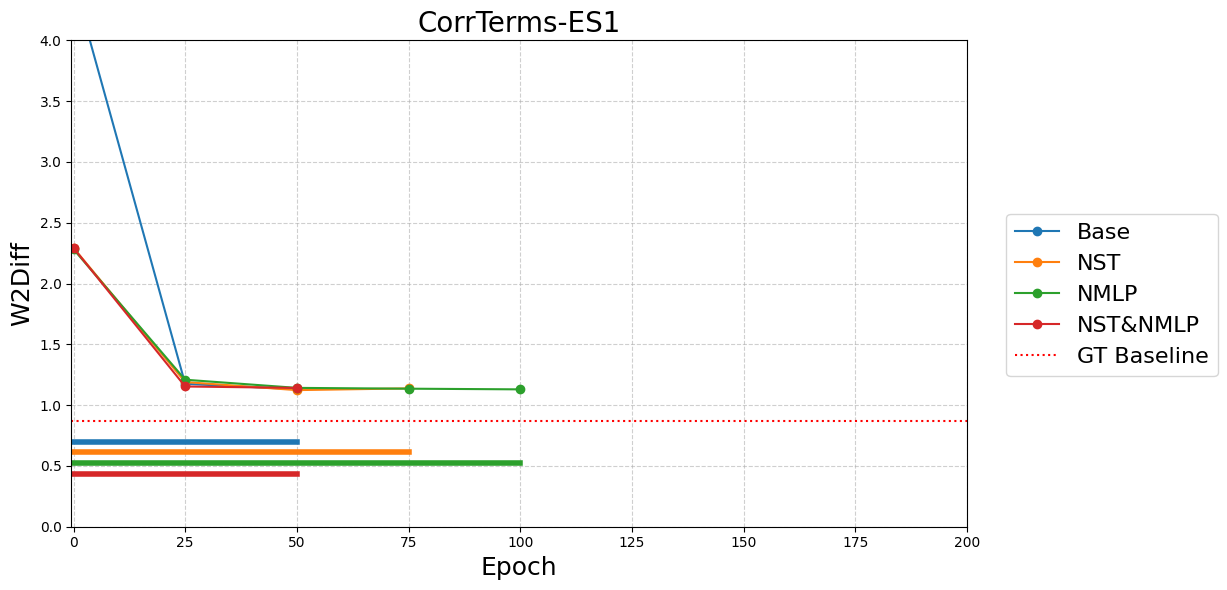

In [21]:
import torch
import os
import matplotlib.pyplot as plt

# This line assumes the file exists at the specified path.
inherent_unc_results = torch.load(os.path.join("save", "benchmark", f"linear_inherent_unc_N10_resample100_len100_10rand.pt"), weights_only=True)
Base_W2 = inherent_unc_results['mean_w2_diff']

folder_names = ['2025-07-06_18-27linear_1_10_60_8192_es_joint_CorrTerms',
                '2025-07-09_19-58linear_1_10_60_8192_es_joint_CorrTerms_nst',
                '2025-07-09_20-33linear_1_10_60_8192_es_joint_CorrTermsnimlp',
                '2025-07-09_19-31linear_1_10_60_8192_es_joint_CorrTerms_nst_nimlp',
            ]

method_names = ['Base',
                'NST', 
                'NMLP',
                'NST&NMLP', 
            ]

# Y-values for the horizontal "training until" lines
training_until_values = [0.8 * Base_W2, 0.7 * Base_W2, 0.6 * Base_W2, 0.5 * Base_W2]

fig_w2diff, ax_w2diff = plt.subplots(figsize=(10, 6))

for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'linear_explode_checks',folder_name, 'training_records.pt')
    # This assumes the files exist and contain the expected data.
    data = torch.load(file_name)
    
    w2_diff, test_epochs = data.get('mean_w2_diff'), data.get('test_epochs')
    
    if method_names[i] == 'Base':
        w2_diff, test_epochs = w2_diff[:3], test_epochs[:3]

    if not w2_diff:
        print(f"Skipping plot for {folder_name} due to missing data.")
        continue
    
    if len(w2_diff) != len(test_epochs):
        print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(w2_diff)}.")
        continue
    
    # Plot the main curve and get its color
    line, = ax_w2diff.plot(test_epochs, w2_diff, marker='o', linestyle='-', label=method_names[i])
    
    # Plot the horizontal line showing training duration
    ax_w2diff.plot([0, test_epochs[-1]], [training_until_values[i], training_until_values[i]], color=line.get_color(), linewidth=4)


ax_w2diff.axhline(y=Base_W2, color='r', linestyle=':', label='GT Baseline')
ax_w2diff.set_ylabel('W2Diff', fontsize=18)
ax_w2diff.set_xlabel('Epoch', fontsize=18) 
ax_w2diff.grid(True, which="both", linestyle='--', alpha=0.6)
ax_w2diff.set_xlim(left=-0.5, right=200)
ax_w2diff.set_ylim(bottom=0, top=4)
ax_w2diff.set_title('CorrTerms-ES1', fontsize=20)
fig_w2diff.tight_layout()
fig_w2diff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# handles, labels = ax_w2diff.get_legend_handles_labels()
# fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))
# ax_legend.axis('off')
# fig_legend.legend(handles, labels, loc='center', ncol=len(method_names) + 2, fontsize=24, frameon=False)

plt.show()

Dynamic: $v_{j+1} = Av_j$, where $A\in \mathbb{R}^{10\times 10}$ is a orthogonal matrix (rotation only).

I did this experimental setting because I doubt if the eigenvalues $\pm$ lead to the explosion issue.

In this case, $A$ is randomly chosen:
| | | | | | | | | | |
|---|---|---|---|---|---|---|---|---|---|
| 0.5403| -0.8415| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.8415| 0.5403| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.6675| -0.7446| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.7446| 0.6675| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.7776| -0.6288| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.6288| 0.7776| 0.0000| 0.0000| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.8678| -0.4969| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.4969| 0.8678| 0.0000| 0.0000|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.9359| -0.3523|
| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.0000| 0.3523| 0.9359|

with eigenvalues: 0.54+0.84i, 0.54-0.84i, 0.67+0.74i, 0.67-0.74i, 0.78+0.63i, 0.78-0.63i, 0.87+0.50i, 0.87-0.50i, 0.94+0.35i, 0.94-0.35i

/tmp/ipykernel_3862784/3036391702.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_name)


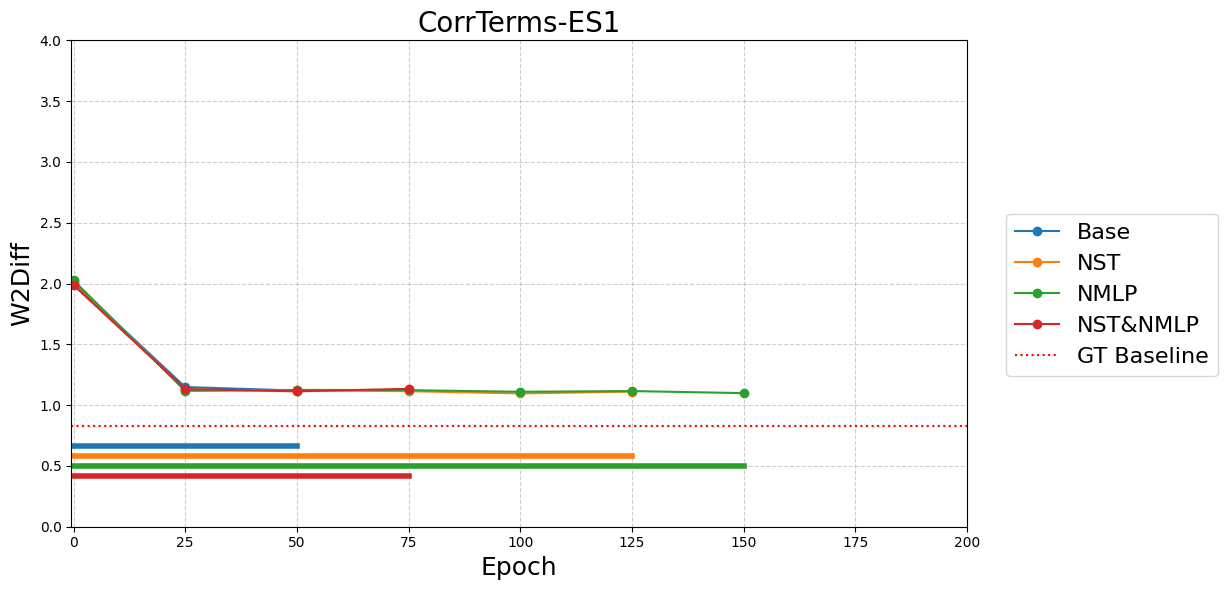

In [22]:
import torch
import os
import matplotlib.pyplot as plt

# This line assumes the file exists at the specified path.
inherent_unc_results = torch.load(os.path.join("save", "benchmark", f"linear_inherent_unc_N10_resample100_len100_10rot.pt"), weights_only=True)
Base_W2 = inherent_unc_results['mean_w2_diff']

folder_names = ['2025-07-10_15-45linear_1_10_60_8192_es_joint_CorrTerms',
                '2025-07-10_18-13linear_1_10_60_8192_es_joint_CorrTerms_nst',
                '2025-07-10_20-12linear_1_10_60_8192_es_joint_CorrTerms_nimlp',
                '2025-07-10_16-48linear_1_10_60_8192_es_joint_CorrTerms_nst_nimlp',
            ]

method_names = ['Base',
                'NST', 
                'NMLP',
                'NST&NMLP', 
            ]

# Y-values for the horizontal "training until" lines
training_until_values = [0.8 * Base_W2, 0.7 * Base_W2, 0.6 * Base_W2, 0.5 * Base_W2]

fig_w2diff, ax_w2diff = plt.subplots(figsize=(10, 6))

for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'linear_explode_checks',folder_name, 'training_records.pt')
    # This assumes the files exist and contain the expected data.
    data = torch.load(file_name)
    
    w2_diff, test_epochs = data.get('mean_w2_diff'), data.get('test_epochs')

    if not w2_diff:
        print(f"Skipping plot for {folder_name} due to missing data.")
        continue
    
    if len(w2_diff) != len(test_epochs):
        print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(w2_diff)}.")
        continue
    
    # Plot the main curve and get its color
    line, = ax_w2diff.plot(test_epochs, w2_diff, marker='o', linestyle='-', label=method_names[i])
    
    # Plot the horizontal line showing training duration
    ax_w2diff.plot([0, test_epochs[-1]], [training_until_values[i], training_until_values[i]], color=line.get_color(), linewidth=4)


ax_w2diff.axhline(y=Base_W2, color='r', linestyle=':', label='GT Baseline')
ax_w2diff.set_ylabel('W2Diff', fontsize=18)
ax_w2diff.set_xlabel('Epoch', fontsize=18) 
ax_w2diff.grid(True, which="both", linestyle='--', alpha=0.6)
ax_w2diff.set_xlim(left=-0.5, right=200)
ax_w2diff.set_ylim(bottom=0, top=4)
ax_w2diff.set_title('CorrTerms-ES1', fontsize=20)
fig_w2diff.tight_layout()
fig_w2diff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# handles, labels = ax_w2diff.get_legend_handles_labels()
# fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))
# ax_legend.axis('off')
# fig_legend.legend(handles, labels, loc='center', ncol=len(method_names) + 2, fontsize=24, frameon=False)

plt.show()

We simplify the problem to test whether the observed "explosion" phenomenon is caused by the dynamic setting itself or by technical issues arising from the high dimensionality. To do this, instead of the 10-dimensional block matrix, we consider a simple 2D case.

Dynamic: $v_{j+1} = Av_j$, where $A\in \mathbb{R}^{2\times 2}$ is an orthogonal matrix (rotation only).

In this case, $A$ is chosen with a rotation angle of 0.5 radians:
$$A = \begin{pmatrix} \cos(0.5) & \sin(0.5) \\ -\sin(0.5) & \cos(0.5) \end{pmatrix} \approx \begin{pmatrix} 0.8776 & 0.4794 \\ -0.4794 & 0.8776 \end{pmatrix}$$

with eigenvalues: $0.8776+0.4794i, 0.8776-0.4794i$.

**In summary, NO explosion happens in this 2-d setting.**

/tmp/ipykernel_3862784/3659004337.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_name)


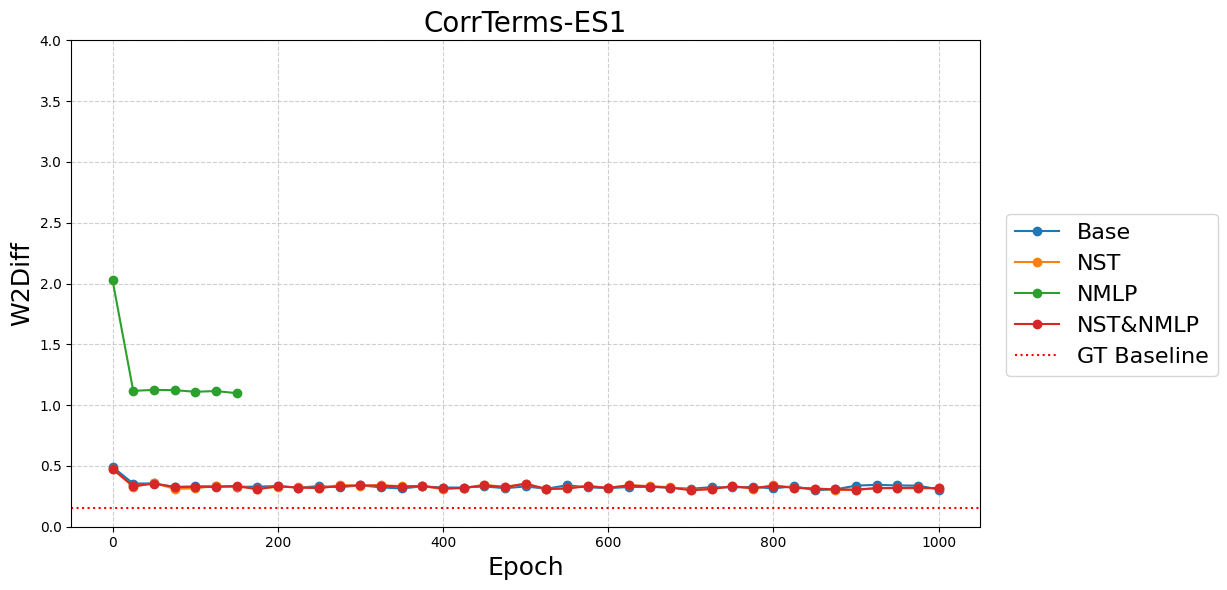

In [25]:
import torch
import os
import matplotlib.pyplot as plt

# This line assumes the file exists at the specified path.
inherent_unc_results = torch.load(os.path.join("save", "benchmark", f"linear_inherent_unc_N10_resample100_len100_2rot.pt"), weights_only=True)
Base_W2 = inherent_unc_results['mean_w2_diff']

folder_names = ['2025-07-10_19-51linear_1_10_60_8192_es_joint_CorrTerms',
                '2025-07-11_02-07linear_1_10_60_8192_es_joint_CorrTerms_nst',
                '2025-07-10_20-12linear_1_10_60_8192_es_joint_CorrTerms_nimlp',
                '2025-07-11_05-14linear_1_10_60_8192_es_joint_CorrTerms_nimlp',
            ]

method_names = ['Base',
                'NST', 
                'NMLP',
                'NST&NMLP', 
            ]

# Y-values for the horizontal "training until" lines
training_until_values = [0.8 * Base_W2, 0.7 * Base_W2, 0.6 * Base_W2, 0.5 * Base_W2]

fig_w2diff, ax_w2diff = plt.subplots(figsize=(10, 6))

for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'linear_explode_checks',folder_name, 'training_records.pt')
    # This assumes the files exist and contain the expected data.
    data = torch.load(file_name)
    
    w2_diff, test_epochs = data.get('mean_w2_diff'), data.get('test_epochs')

    if not w2_diff:
        print(f"Skipping plot for {folder_name} due to missing data.")
        continue
    
    if len(w2_diff) != len(test_epochs):
        print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(w2_diff)}.")
        continue
    
    # Plot the main curve and get its color
    line, = ax_w2diff.plot(test_epochs, w2_diff, marker='o', linestyle='-', label=method_names[i])
    
    # Plot the horizontal line showing training duration
    # ax_w2diff.plot([0, test_epochs[-1]], [training_until_values[i], training_until_values[i]], color=line.get_color(), linewidth=4)


ax_w2diff.axhline(y=Base_W2, color='r', linestyle=':', label='GT Baseline')
ax_w2diff.set_ylabel('W2Diff', fontsize=18)
ax_w2diff.set_xlabel('Epoch', fontsize=18) 
ax_w2diff.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_w2diff.set_xlim(left=-0.5, right=200)
ax_w2diff.set_ylim(bottom=0, top=4)
ax_w2diff.set_title('CorrTerms-ES1', fontsize=20)
fig_w2diff.tight_layout()
fig_w2diff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# handles, labels = ax_w2diff.get_legend_handles_labels()
# fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))
# ax_legend.axis('off')
# fig_legend.legend(handles, labels, loc='center', ncol=len(method_names) + 2, fontsize=24, frameon=False)

plt.show()

To further investigate the cause of the explosion in our CorrTerms method, we consider 2D periodic problems with a fixed Hamiltonian. The Hamiltonian is defined as $$H(x,y) = x^2 + V(y).$$ We analyze two specific cases for the potential $V(y)$.

1.  **Harmonic Oscillator:** The potential is $V(y) = y^2$. The corresponding ODEs are:
    $$
    \begin{aligned}
    \frac{dx}{dt} &= \omega y \\
    \frac{dy}{dt} &= -\omega x
    \end{aligned}
    $$

2.  **Double-Well Potential:** The potential is given by $V(y) = \frac{a}{4}y^4 - \frac{b}{2}y^2$. The corresponding ODEs are:
    $$
    \begin{aligned}
    \frac{dx}{dt} &= y \\
    \frac{dy}{dt} &= b x - a x^3
    \end{aligned}
    $$

For both systems, the ODEs are solved using the 4th-order Runge-Kutta (RK4) method. We generate an approximate ground-truth filtering distribution by employing a particle filter with 1,000,000 particles.

In both of these settings, our CorrTerms method was trained successfully for 1000 epochs without encountering any explosion issues. This result further suggests that the explosion problem does not manifest in inexact schemes.

### Conclusion

To summarize, we attribute the **explosion problem** during training to an **overfitting** issue. Our findings suggest that the learned scheme overfits to a specific subset of random samples, which leads to a sharp degradation in performance and a subsequent loss explosion when trained on different random samples. This conclusion is based on several key findings from our experiments:

1.  The training explosion was observed exclusively in the **linear-Gaussian problem**. It did not occur in any of the other tested **nonlinear systems**, including the Hamiltonian Double-well potential, Lorenz 63, Lorenz 96, and the Kuramoto-Sivashinsky (KS) equation. We hypothesize this is because, in the linear-Gaussian context, our CorrTerms method contains the EnKF, which is an asymptotically exact scheme. Conversely, in the nonlinear systems, the EnKF has an inherent model error for the trained correction terms.

2.  Within the linear problem itself, the explosion did not occur when trajectories were **unbounded** (i.e., when the transition matrix `A` had eigenvalues with magnitudes greater than 1). The issue appeared exclusively when `A` was an **orthogonal matrix**, where the state norm is conserved. We reason that in the unbounded case, the fixed-scale random noise becomes negligible as the state's magnitude grows. In contrast, for an orthogonal `A`, the state norm remains bounded. Given that our initial state norm was approximately 1-10 and the noise standard deviation was 1, the noise level was always significant relative to the state's magnitude. This condition makes it much easier for the model to overfit to the specific realization of noise in the training data, causing instability.

3.  We also found that in the linear problem with an orthogonal matrix `A`, the explosion occurs in **higher dimensions (d=10)** but is far less frequent in **lower dimensions (d=2)**. This points to overfitting from another perspective. With a fixed amount of training data, a high-dimensional space is much more sparse. Therefore, a model that overfits learns a narrow data representation and is more likely to fail on unseen samples. In contrast, the low-dimensional space is denser, so the training data is more likely to cover most scenarios, making even an overfit model appear more robust.

4.  We explored several technical methods commonly used to combat overfitting, including **weight decay** (L2 regularization), using an **adaptive learning rate**, applying a **normalized loss** function, and **feeding the random sample's seed into the neural network as an input**. Each of these techniques was successful in delaying the onset of the explosion.